In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load dataset
df = pd.read_csv('/content/games_dataset.csv')

In [ ]:
#Convert Categorical Values into numeric
#Use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown = 'ignore'),
            ['Genre', 'Platform']
        ),
        (
            'numeric',
            'passthrough',
            ['Release Year']
        )
    ]
)

In [ ]:
#Split into Training and Testing Data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

In [ ]:
#Build the Predictive Model
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        (
            'regressor',
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

In [ ]:
#Train the Model
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Genre', 'Platform']),
                                                 ('numeric', 'passthrough',
                                                  ['Release Year'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [ ]:
#Make Predictions
y_pred = model.predict(x_test)
print(y_pred[:10])

[5.69038379 5.40074395 3.64951761 5.85379326 3.27959803 6.46709933
 5.9688813  5.7697226  8.25684047 5.82759616]


In [ ]:
#Evaluate the Model
#1st MAE = Mean Absolute Error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.421408873104373


In [ ]:
#2nd RMSE = Root Mean Squared Error
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)
print("Root Mean Squared Error:", rmse)


Root Mean Squared Error: 2.907000932379836


In [ ]:
#3rd R2 Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2:", r2)

R2: -0.25336426962851655


In [ ]:
#Feature Selection
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': result.importances_mean
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance)


        Feature  Importance
0         Genre    0.066326
2  Release Year    0.048250
1      Platform    0.036821


In [ ]:
#Genre is the most influential of the three feature,
#Release Year is the second most influential.
#Platform contributes the least.

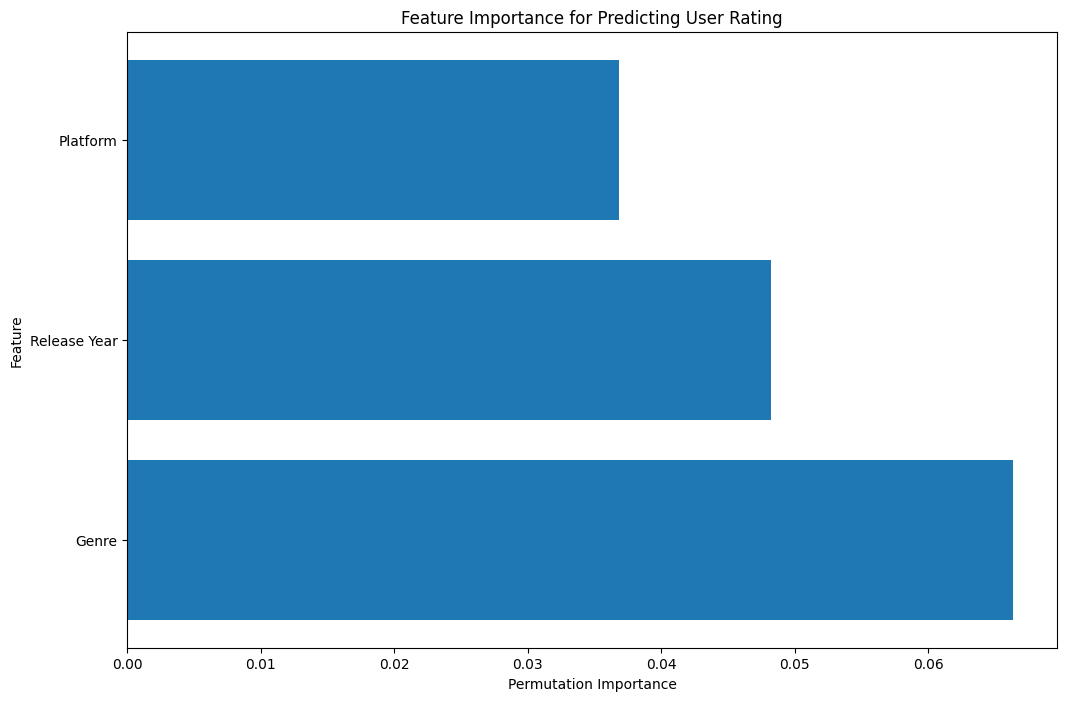

In [ ]:
#Visualize Feature Importance
plt.figure(figsize=(12,8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Predicting User Rating")
plt.show()

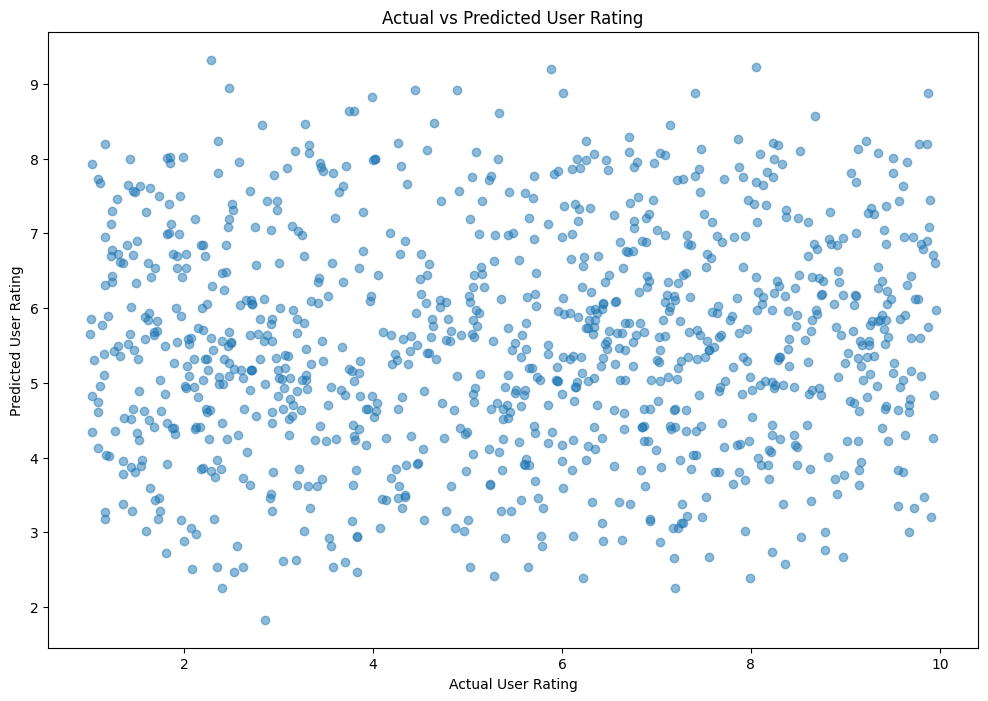

In [ ]:
#Actual vs Predicted Rating
plt.figure(figsize=(12,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)
plt.xlabel("Actual User Rating")
plt.ylabel("Predicted User Rating")
plt.title("Actual vs Predicted User Rating")
plt.show()